# Comparative Analysis of Mutation Effect on Immune Escape

In [1]:
import pandas as pd
import numpy as np
import json

from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Read in data

In [2]:
def get_position(mutation):
    pos = [_ for _ in mutation if _.isdigit()]
    pos = ''.join(pos)
    pos = int(pos)
    return pos

In [3]:
# Read in CovDB results
covdb_date = '2024-11-20'
covdb = pd.read_csv(f'results/covdb/{covdb_date}/mutation_effects.csv')
# with open(f'results/covdb/{covdb_date}/plasma_biases.json', 'r') as handle:
#     plasma_biases = json.load(handle)
with open(f'results/covdb/{covdb_date}/assay_biases.json', 'r') as handle:
    assay_biases = json.load(handle)



# Read in Neutralization results
neut_date = '2024-10-31'
neut = pd.read_csv(f'results/neutralization/{neut_date}/mutation_effects_within_pools.csv')
neut_avg = pd.read_csv(f'results/neutralization/{neut_date}/mutation_effects_across_pools.csv')



# Read in EVEScape data
evescape = pd.read_csv('data/EVEscape/spike_evescape_predictions.csv').drop(columns='Unnamed: 0')
evescape['Mutation'] = evescape['wt'] + evescape['i'].astype(str) + evescape['mut']



# Gather DMS data
dms = evescape[['Mutation', 'i', 'wt', 'mut', 'bloom_expression', 'bloom_ace2_binding', 
                'chan_expression', 'chan_ace2_binding', 'max_escape_bloom', 'max_escape_xie']
              ].dropna().reset_index(drop=True)
# dms['max_escape_bloom'] = np.exp(dms['max_escape_bloom'])


# PyR0
pyro_file = 'data/PyR0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])
pyro['Position'] = pyro['Mutation'].apply(lambda x: get_position(x))


# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])
bvas['Position'] = bvas['Mutation'].apply(lambda x: get_position(x))




# Read in experimental data
data_dir = 'data/Supp_Material/'
filename = 'Supp_TableS6_Neutralization_Data.csv'
neutralization = pd.read_csv(data_dir+filename)
neutralization = pd.melt(neutralization, id_vars='Name').rename(columns={'variable':'Pool', 'value':'Neutralization'})   # unpivot data
neutralization['Name'] = neutralization['Name'].apply(lambda x: x.capitalize() if x.islower() else x)   # clean up names to make sure VoCs match
neutralization['Neutralization'] = pd.to_numeric(neutralization['Neutralization'].apply(lambda x: 10 if x=='<20' else x))   # impute limits of detection

# Calculate log fold reduction
norm = neutralization['Neutralization'][neutralization['Name']=='WuG'].mean()
neutralization['Log fold reduction'] = np.log(norm / neutralization['Neutralization'])

# Rename pools
neutralization['Pool'] = neutralization['Pool'].apply(lambda x: x if x=='Bi-valent Boost' else x.split('-')[0])

# Add in Base VoC
neutralization = pd.merge(neutralization,
                          pd.read_csv('data/Supp_Material/Supp_TableS4_Infectivity_Data.csv', usecols=['Name', 'base_voc']).replace('BA.4/5', 'BA.5'),
                          on='Name')

# Rename columns
neutralization = neutralization.rename(columns={'Name - Construct':'Name', 'base_voc':'Base VoC'})
neutralization = neutralization[['Name', 'Base VoC', 'Pool', 'Log fold reduction']].drop_duplicates().reset_index(drop=True)

# Mutations
data_dir = 'data/Supp_Material/'
filename = 'construct_mutations.csv'
cols = ['Name', 'All mutations']
mutations = pd.read_csv(data_dir+filename, usecols=cols)
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list

# Remove D614G
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace('D614G,',''))
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(',D614G',''))
mutations['All mutations'].loc[mutations['Name']=='WuG'] = None
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'All mutations':None}])])

mutations = mutations[mutations['All mutations']!='--']

mut_constructs = mutations['Name'].unique()

neutralization = neutralization.merge(mutations, on='Name', how='inner').drop_duplicates()

## Correlations

In [4]:
def corr(x, y, df):
    series1 = df[[x,y]].dropna()[x]
    series2 = df[[x,y]].dropna()[y]
    R, p = pearsonr(series1, series2)
    return R, p

def annotate(ax, x, y, df, t, n=60):
    if len(df[[x,y,t]].dropna()) <= n:
        # Label all points
        for label in df[t].dropna():
            xi = df[x][df[t]==label].item()
            yi = df[y][df[t]==label].item()
            if not pd.isna(xi) and not pd.isna(yi):
                ax.text(xi, yi, label, rotation=20, fontsize=7)
                
    else:
        # grab at most n outliers and label
        labels = df.sort_values(by=x).head(int(n/4))[t].tolist() + \
                 df.sort_values(by=x).tail(int(n/4))[t].tolist() + \
                 df.sort_values(by=y).head(int(n/4))[t].tolist() + \
                 df.sort_values(by=y).tail(int(n/4))[t].tolist()
        for label in labels:
            xi = df[x][df[t]==label].item()
            yi = df[y][df[t]==label].item()
            if not pd.isna(xi) and not pd.isna(yi):
                ax.text(xi, yi, label, rotation=20, fontsize=7)
                
def plot(x, y, df, t=None, logistic=False, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(8,8))
    R, p = corr(x,y,df)
    sns.regplot(x=x,
                y=y,
                data=df,
                label='R={:.2f}\np={:.2e}'.format(R,p),
                logistic=logistic,
                ax=ax);
    ax.legend()

    # Annotate muts
    if t:
        annotate(ax, x, y, df, t, **kwargs)

    ax.set_title(f'{x} vs. {y} on {len(df[[x,y]].drop_duplicates())} mutations');
    
    return fig, ax

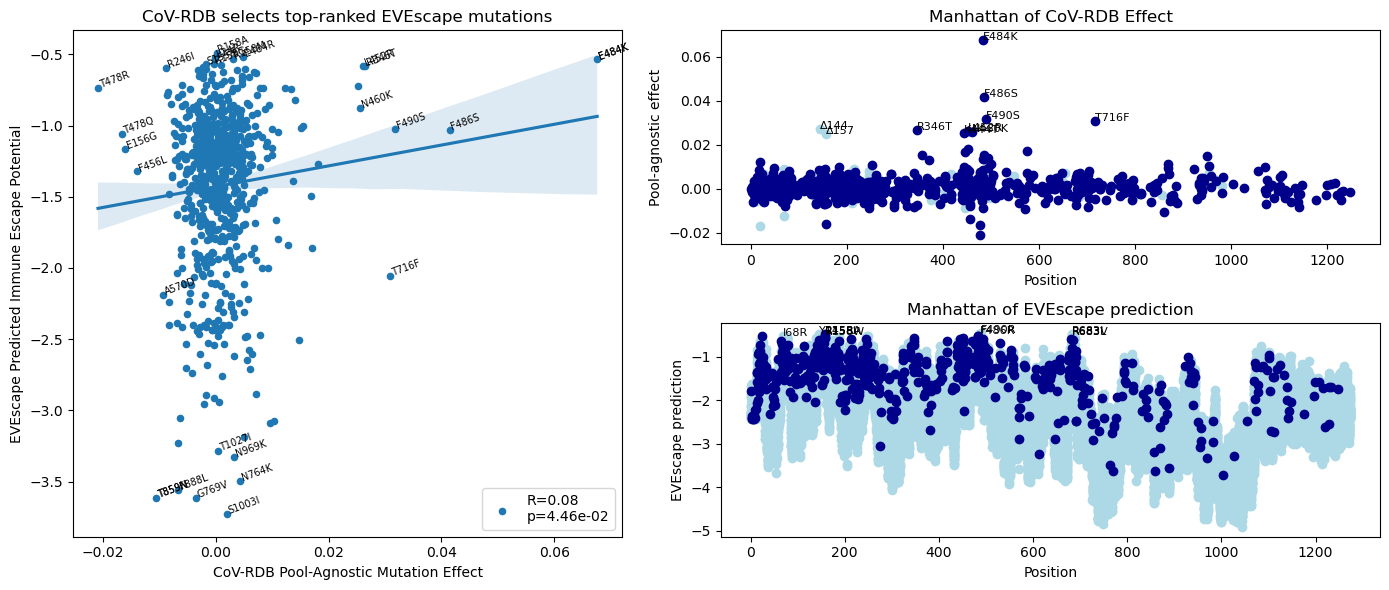

In [5]:
covdb_x_evescape = pd.merge(covdb, evescape, on='Mutation')

# Create a figure
fig = plt.figure(figsize=(14, 6))

# Define the grid with specific height and width ratios
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])
f=8
var1 = 'μ_β'; var2 = 'evescape';

# Create the first column subplot (spanning all rows in the first column)
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_title('CoV-RDB selects top-ranked EVEscape mutations');
R, p = corr(var1,var2,covdb_x_evescape)
# xy = np.stack([covdb_x_evescae[var1].values,covdb_x_evescape[var2].values])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = covdb_x_evescae[var1][idx], covdb_x_evescape[var2][idx], z[idx]
# ax1.scatter(x, y, c=z, s=20, cmap='rocket')
ax1.scatter(covdb_x_evescape[var1], covdb_x_evescape[var2], s=20, color='tab:blue');
sns.regplot(x=var1,
            y=var2,
            data=covdb_x_evescape,
            label='R={:.2f}\np={:.2e}'.format(R,p),
            scatter=False,
            ax=ax1);
annotate(ax1, var1, var2, covdb_x_evescape, 'Mutation', n=30)
ax1.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])
ax1.set_xlabel('CoV-RDB Pool-Agnostic Mutation Effect');
ax1.set_ylabel('EVEscape Predicted Immune Escape Potential');

# Create the first column subplot (spanning all rows in the first column)
ax2 = fig.add_subplot(gs[0, 1])
outset = pd.merge(covdb, covdb_x_evescape, on='Mutation', how='left').rename(columns={f'{var1}_x':var1})
outset = outset[outset['evescape'].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax2.plot(positions, outset[var1], color='lightblue', marker='o', linestyle='')
ax2.plot(covdb_x_evescape['i'], covdb_x_evescape[var1], color='darkblue', marker='o', linestyle='')
for i, row in covdb.sort_values(by=var1, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        pos = int(''.join([c for c in row['Mutation'] if c.isdigit()]))
        ax2.text(pos, row[var1], row['Mutation'], fontsize=f)
    else:
        break
ax2.set_xlabel('Position')
ax2.set_ylabel('Pool-agnostic effect');
ax2.set_title('Manhattan of CoV-RDB Effect');

# Create the first column subplot (spanning all rows in the first column)
ax3 = fig.add_subplot(gs[1, 1])
outset = pd.merge(evescape, covdb_x_evescape, on='Mutation', how='left').rename(columns={f'{var2}_x':var2})
outset = outset[outset['μ_β'].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax3.plot(positions, outset[var2], color='lightblue', marker='o', linestyle='')
ax3.plot(covdb_x_evescape['i'], covdb_x_evescape[var2], color='darkblue', marker='o', linestyle='')
for i, row in evescape.sort_values(by=var2, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        ax3.text(row['i'], row[var2], row['Mutation'], fontsize=f)
    else:
        break
ax3.set_xlabel('Position')
ax3.set_ylabel('EVEscape prediction');
ax3.set_title('Manhattan of EVEscape prediction');

fig.tight_layout()

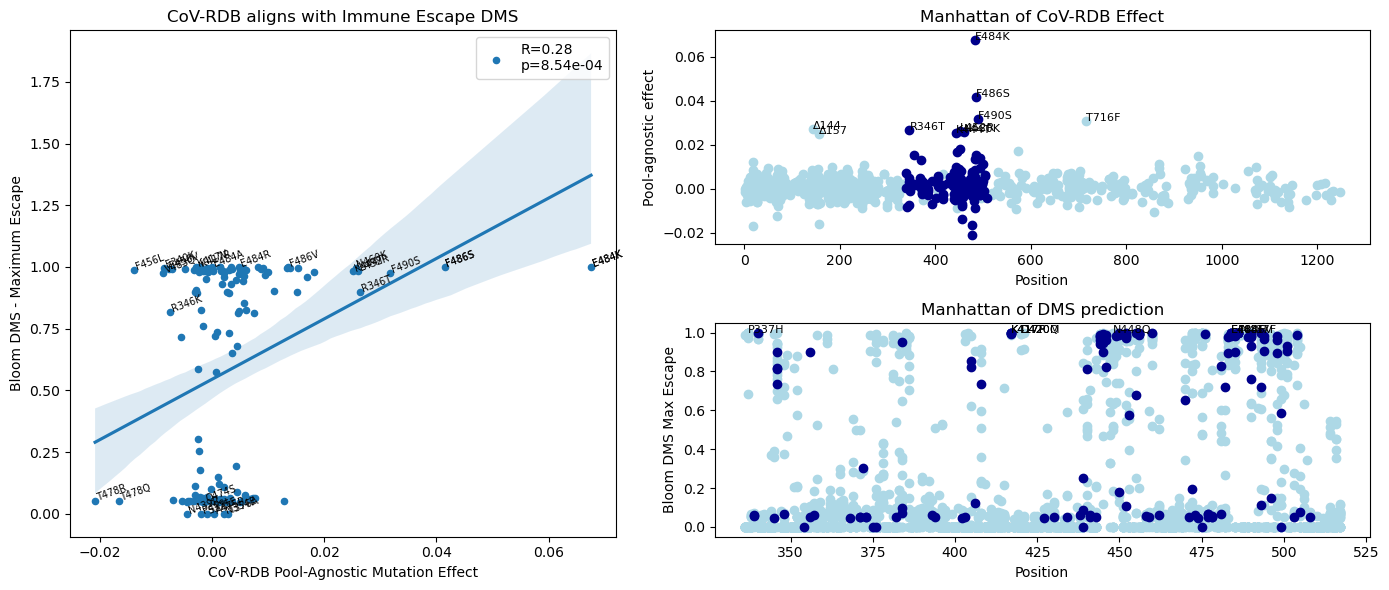

In [6]:
covdb_x_dms = pd.merge(covdb, dms, on='Mutation')
# Create a figure
fig = plt.figure(figsize=(14, 6))

# Define the grid with specific height and width ratios
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])
f=8
var1 = 'μ_β'; var2 = 'max_escape_bloom';

# Create the first column subplot (spanning all rows in the first column)
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_title('CoV-RDB aligns with Immune Escape DMS');
R, p = corr(var1,var2,covdb_x_dms)
# xy = np.stack([covdb_x_evescae[var1].values,covdb_x_evescape[var2].values])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = covdb_x_evescae[var1][idx], covdb_x_evescape[var2][idx], z[idx]
# ax1.scatter(x, y, c=z, s=20, cmap='rocket')
ax1.scatter(covdb_x_dms[var1], covdb_x_dms[var2], s=20, color='tab:blue');
sns.regplot(x=var1,
            y=var2,
            data=covdb_x_dms,
            label='R={:.2f}\np={:.2e}'.format(R,p),
            scatter=False,
            ax=ax1);
annotate(ax1, var1, var2, covdb_x_dms, 'Mutation', n=30)
ax1.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])
ax1.set_xlabel('CoV-RDB Pool-Agnostic Mutation Effect');
ax1.set_ylabel('Bloom DMS - Maximum Escape');

# Create the first column subplot (spanning all rows in the first column)
ax2 = fig.add_subplot(gs[0, 1])
outset = pd.merge(covdb, covdb_x_dms, on='Mutation', how='left').rename(columns={f'{var1}_x':var1})
outset = outset[outset['max_escape_bloom'].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax2.plot(positions, outset[var1], color='lightblue', marker='o', linestyle='')
ax2.plot(covdb_x_dms['i'], covdb_x_dms[var1], color='darkblue', marker='o', linestyle='')
for i, row in covdb.sort_values(by=var1, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        pos = int(''.join([c for c in row['Mutation'] if c.isdigit()]))
        ax2.text(pos, row[var1], row['Mutation'], fontsize=f)
    else:
        break
ax2.set_xlabel('Position')
ax2.set_ylabel('Pool-agnostic effect');
ax2.set_title('Manhattan of CoV-RDB Effect');

# Create the first column subplot (spanning all rows in the first column)
ax3 = fig.add_subplot(gs[1, 1])
outset = pd.merge(dms, covdb_x_dms, on='Mutation', how='left').rename(columns={f'{var2}_x':var2})
outset = outset[outset['μ_β'].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax3.plot(positions, outset[var2], color='lightblue', marker='o', linestyle='')
ax3.plot(covdb_x_dms['i'], covdb_x_dms[var2], color='darkblue', marker='o', linestyle='')
for i, row in dms.sort_values(by=var2, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        ax3.text(row['i'], row[var2], row['Mutation'], fontsize=f)
    else:
        break
ax3.set_xlabel('Position')
ax3.set_ylabel('Bloom DMS Max Escape');
ax3.set_title('Manhattan of DMS prediction');

fig.tight_layout()

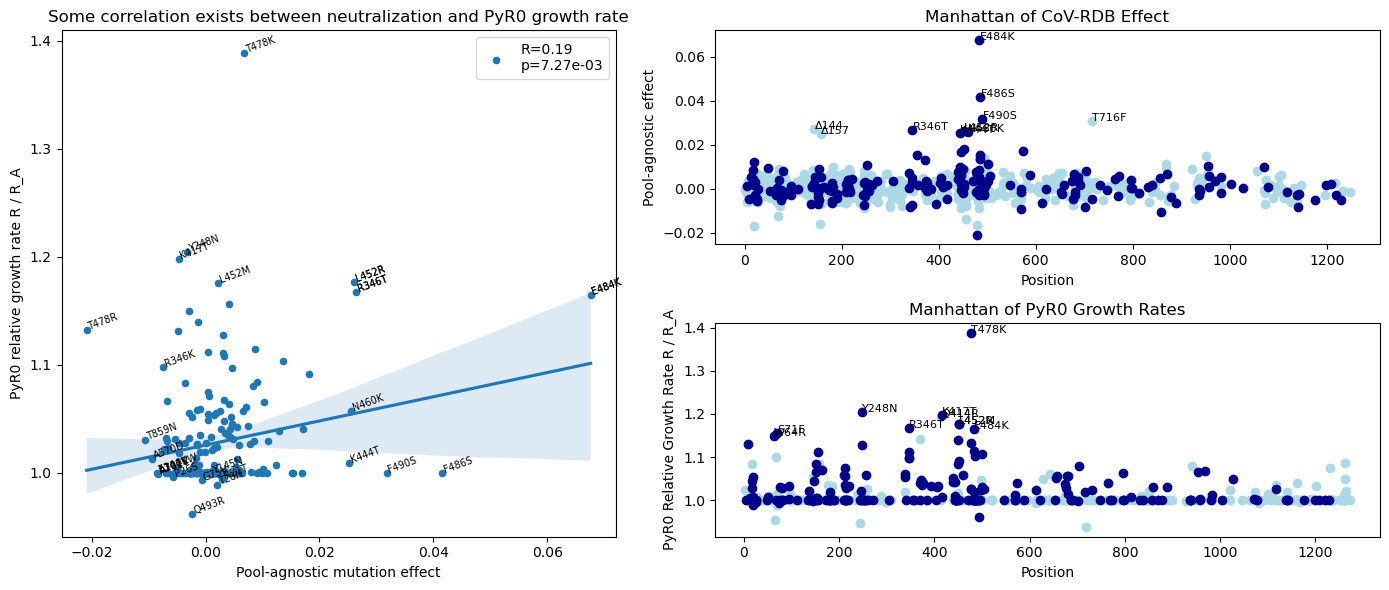

In [7]:
covdb_x_pyro = pd.merge(covdb, pyro, on='Mutation')

# Create a figure
fig = plt.figure(figsize=(14, 6))

# Define the grid with specific height and width ratios
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])
f=8
var1 = 'μ_β'; var2 = 'R / R_A';

# Create the first column subplot (spanning all rows in the first column)
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_title('Some correlation exists between neutralization and PyR0 growth rate');
R, p = corr(var1,var2,covdb_x_pyro)
# xy = np.stack([covdb_x_evescae[var1].values,covdb_x_evescape[var2].values])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = covdb_x_evescae[var1][idx], covdb_x_evescape[var2][idx], z[idx]
# ax1.scatter(x, y, c=z, s=20, cmap='rocket')
ax1.scatter(covdb_x_pyro[var1], covdb_x_pyro[var2], s=20, color='tab:blue');
sns.regplot(x=var1,
            y=var2,
            data=covdb_x_pyro,
            label='R={:.2f}\np={:.2e}'.format(R,p),
            scatter=False,
            ax=ax1);
annotate(ax1, var1, var2, covdb_x_pyro, 'Mutation', n=30)
ax1.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])
ax1.set_xlabel('Pool-agnostic mutation effect')
ax1.set_ylabel('PyR0 relative growth rate R / R_A')

# Create the first column subplot (spanning all rows in the first column)
ax2 = fig.add_subplot(gs[0, 1])
outset = pd.merge(covdb, covdb_x_pyro, on='Mutation', how='left').rename(columns={f'{var1}_x':var1})
outset = outset[outset[var2].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax2.plot(positions, outset[var1], color='lightblue', marker='o', linestyle='')
ax2.plot(covdb_x_pyro['Position'], covdb_x_pyro[var1], color='darkblue', marker='o', linestyle='')
for i, row in covdb.sort_values(by=var1, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        pos = int(''.join([c for c in row['Mutation'] if c.isdigit()]))
        ax2.text(pos, row[var1], row['Mutation'], fontsize=f)
    else:
        break
ax2.set_xlabel('Position')
ax2.set_ylabel('Pool-agnostic effect');
ax2.set_title('Manhattan of CoV-RDB Effect');

# Create the first column subplot (spanning all rows in the first column)
ax3 = fig.add_subplot(gs[1, 1])
outset = pd.merge(pyro, covdb_x_pyro, on='Mutation', how='left').rename(columns={f'{var2}_x':var2})
outset = outset[outset[var1].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax3.plot(positions, outset[var2], color='lightblue', marker='o', linestyle='')
ax3.plot(covdb_x_pyro['Position'], covdb_x_pyro[var2], color='darkblue', marker='o', linestyle='')
for i, row in pyro.sort_values(by=var2, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        ax3.text(row['Position'], row[var2], row['Mutation'], fontsize=f)
    else:
        break
ax3.set_xlabel('Position')
ax3.set_ylabel('PyR0 Relative Growth Rate R / R_A');
ax3.set_title('Manhattan of PyR0 Growth Rates');

fig.tight_layout()

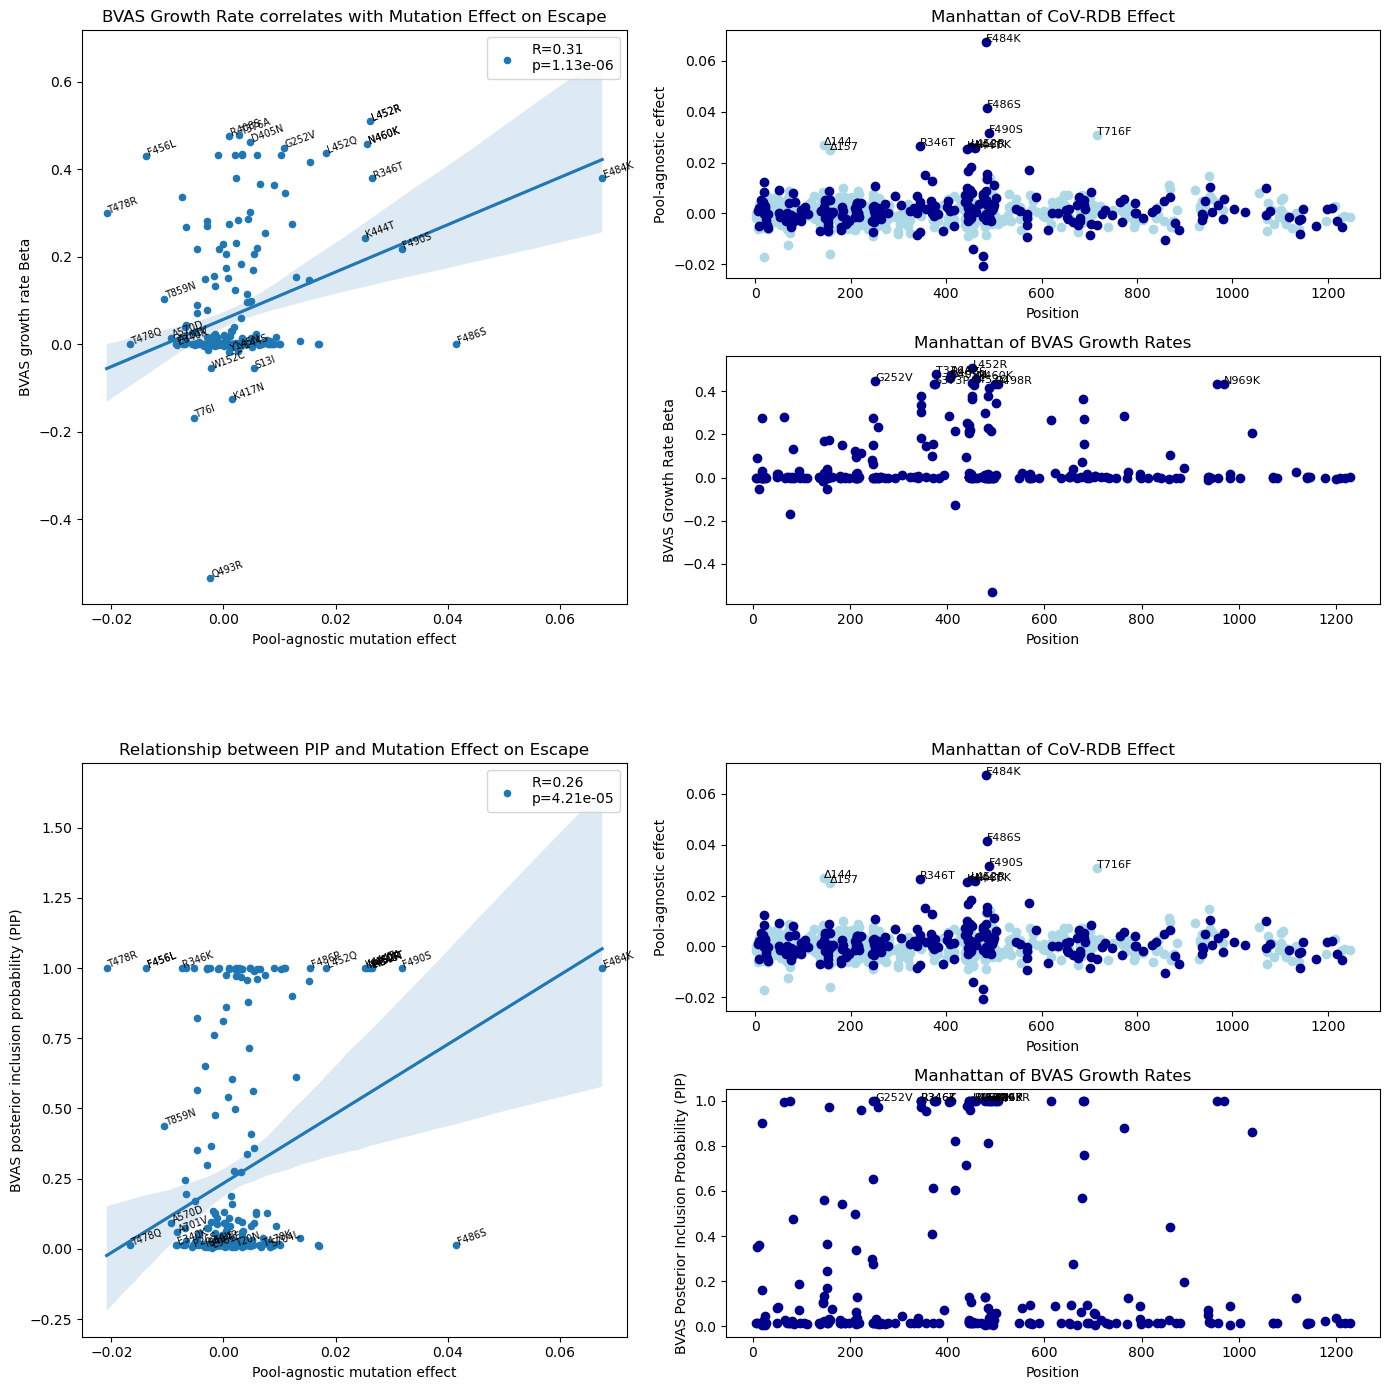

In [8]:
covdb_x_bvas = pd.merge(covdb, bvas, on='Mutation')

# Create a figure
fig = plt.figure(figsize=(14, 14))

# Define the grid with specific height and width ratios
gs = gridspec.GridSpec(5, 2, width_ratios=[1, 1.2], height_ratios=[1, 1, 0.01, 1, 1])
f=8
var1 = 'μ_β'; var2 = 'Beta';

# Create the first column subplot (spanning all rows in the first column)
ax1 = fig.add_subplot(gs[:2, 0])
ax1.set_title('BVAS Growth Rate correlates with Mutation Effect on Escape');
R, p = corr(var1,var2,covdb_x_bvas)
# xy = np.stack([covdb_x_evescae[var1].values,covdb_x_evescape[var2].values])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = covdb_x_evescae[var1][idx], covdb_x_evescape[var2][idx], z[idx]
# ax1.scatter(x, y, c=z, s=20, cmap='rocket')
ax1.scatter(covdb_x_bvas[var1], covdb_x_bvas[var2], s=20, color='tab:blue');
sns.regplot(x=var1,
            y=var2,
            data=covdb_x_bvas,
            label='R={:.2f}\np={:.2e}'.format(R,p),
            scatter=False,
            ax=ax1);
annotate(ax1, var1, var2, covdb_x_bvas, 'Mutation', n=30)
ax1.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])
ax1.set_xlabel('Pool-agnostic mutation effect')
ax1.set_ylabel('BVAS growth rate Beta')

# Create the first column subplot (spanning all rows in the first column)
ax2 = fig.add_subplot(gs[0, 1])
outset = pd.merge(covdb, covdb_x_bvas, on='Mutation', how='left').rename(columns={f'{var1}_x':var1})
outset = outset[outset[var2].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax2.plot(positions, outset[var1], color='lightblue', marker='o', linestyle='')
ax2.plot(covdb_x_bvas['Position'], covdb_x_bvas[var1], color='darkblue', marker='o', linestyle='')
for i, row in covdb.sort_values(by=var1, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        pos = int(''.join([c for c in row['Mutation'] if c.isdigit()]))
        ax2.text(pos, row[var1], row['Mutation'], fontsize=f)
    else:
        break
ax2.set_xlabel('Position')
ax2.set_ylabel('Pool-agnostic effect');
ax2.set_title('Manhattan of CoV-RDB Effect');

# Create the first column subplot (spanning all rows in the first column)
ax3 = fig.add_subplot(gs[1, 1])
outset = pd.merge(pyro, covdb_x_bvas, on='Mutation', how='left').rename(columns={f'{var2}_x':var2})
outset = outset[outset[var1].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax3.plot(positions, outset[var2], color='lightblue', marker='o', linestyle='')
ax3.plot(covdb_x_bvas['Position'], covdb_x_bvas[var2], color='darkblue', marker='o', linestyle='')
for i, row in bvas.sort_values(by=var2, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        ax3.text(row['Position'], row[var2], row['Mutation'], fontsize=f)
    else:
        break
ax3.set_xlabel('Position')
ax3.set_ylabel('BVAS Growth Rate Beta');
ax3.set_title('Manhattan of BVAS Growth Rates');






var1 = 'μ_β'; var2 = 'PIP';

# Create the first column subplot (spanning all rows in the first column)
ax4 = fig.add_subplot(gs[-2:, 0])
ax4.set_title('Relationship between PIP and Mutation Effect on Escape');
R, p = corr(var1,var2,covdb_x_bvas)
# xy = np.stack([covdb_x_evescae[var1].values,covdb_x_evescape[var2].values])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = covdb_x_evescae[var1][idx], covdb_x_evescape[var2][idx], z[idx]
# ax1.scatter(x, y, c=z, s=20, cmap='rocket')
ax4.scatter(covdb_x_bvas[var1], covdb_x_bvas[var2], s=20, color='tab:blue');
sns.regplot(x=var1,
            y=var2,
            data=covdb_x_bvas,
            label='R={:.2f}\np={:.2e}'.format(R,p),
            scatter=False,
            ax=ax4);
annotate(ax4, var1, var2, covdb_x_bvas, 'Mutation', n=30)
ax4.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])
ax4.set_xlabel('Pool-agnostic mutation effect')
ax4.set_ylabel('BVAS posterior inclusion probability (PIP)')

# Create the first column subplot (spanning all rows in the first column)
ax5 = fig.add_subplot(gs[-2, 1])
outset = pd.merge(covdb, covdb_x_bvas, on='Mutation', how='left').rename(columns={f'{var1}_x':var1})
outset = outset[outset[var2].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax5.plot(positions, outset[var1], color='lightblue', marker='o', linestyle='')
ax5.plot(covdb_x_bvas['Position'], covdb_x_bvas[var1], color='darkblue', marker='o', linestyle='')
for i, row in covdb.sort_values(by=var1, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        pos = int(''.join([c for c in row['Mutation'] if c.isdigit()]))
        ax5.text(pos, row[var1], row['Mutation'], fontsize=f)
    else:
        break
ax5.set_xlabel('Position')
ax5.set_ylabel('Pool-agnostic effect');
ax5.set_title('Manhattan of CoV-RDB Effect');

# Create the first column subplot (spanning all rows in the first column)
ax6 = fig.add_subplot(gs[-1, 1])
outset = pd.merge(pyro, covdb_x_bvas, on='Mutation', how='left').rename(columns={f'{var2}_x':var2})
outset = outset[outset[var1].isna()]
positions = [int(''.join(filter(str.isdigit, c))) for c in outset['Mutation']]
ax6.plot(positions, outset[var2], color='lightblue', marker='o', linestyle='')
ax6.plot(covdb_x_bvas['Position'], covdb_x_bvas[var2], color='darkblue', marker='o', linestyle='')
for i, row in bvas.sort_values(by=var2, ascending=False).reset_index(drop=True).iterrows():
    if i<10:
        ax6.text(row['Position'], row[var2], row['Mutation'], fontsize=f)
    else:
        break
ax6.set_xlabel('Position')
ax6.set_ylabel('BVAS Posterior Inclusion Probability (PIP)');
ax6.set_title('Manhattan of BVAS Growth Rates');

fig.tight_layout()

## Model Predictions vs Observations

In [9]:
# Get mutations present in experiements, covdb, and evescape
experiment_mutations = set(','.join([muts for muts in neutralization['All mutations'].tolist() if muts is not None]).split(','))
modeled_mutations = set(covdb['Mutation'].tolist())
evescape_mutations = set(evescape['Mutation'].tolist())
unmodeled_mutations = experiment_mutations - modeled_mutations
nonevescape_mutations = experiment_mutations - evescape_mutations

In [10]:
# Calibrate EVEscape to fit data
# Regress observed values (covdb) over predicted values (EVEscape) to get a calibration factor
neutralization_sub = neutralization[neutralization['All mutations'].apply(lambda x: x is not None and np.all([mut not in x for mut in nonevescape_mutations]))]

# Make EVEscape predictions for neutralization_sub
neutralization_sub['EVEscape prediction'] = neutralization_sub['All mutations'].apply(lambda x: 
                                                                                          evescape[evescape['Mutation'].apply(lambda y: y in x)]['evescape'].sum()
                                                                                     )
reg = LinearRegression().fit(neutralization_sub[['EVEscape prediction']], neutralization_sub[['Log fold reduction']])

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_19083/929934041.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neutralization_sub['EVEscape prediction'] = neutralization_sub['All mutations'].apply(lambda x:


In [11]:
# Predict log fold reduction using EVEscape
def predict_evescape(x):
    muts = set(x.split(',') if x else []) 
    if muts - evescape_mutations == set() and muts:
        prediction = evescape[evescape['Mutation'].apply(lambda y: y in muts)]['evescape'].sum() * reg.coef_ + reg.intercept_
        return prediction.item()
    else:
        return None
    
neutralization['EVEscape prediction'] = neutralization['All mutations'].apply(lambda x: predict_evescape(x))

# Predict log fold reduction using covdb inference model
def predict_model(x):
    muts = set(x.split(',') if x else []) 
    if muts - modeled_mutations == set() and muts:
        prediction = covdb[covdb['Mutation'].apply(lambda y: y in muts)]['μ_β'].sum() + assay_biases['Pseudovirus']
        return prediction.item()
    else:
        return None

neutralization['Model prediction'] = neutralization['All mutations'].apply(lambda x: predict_model(x))

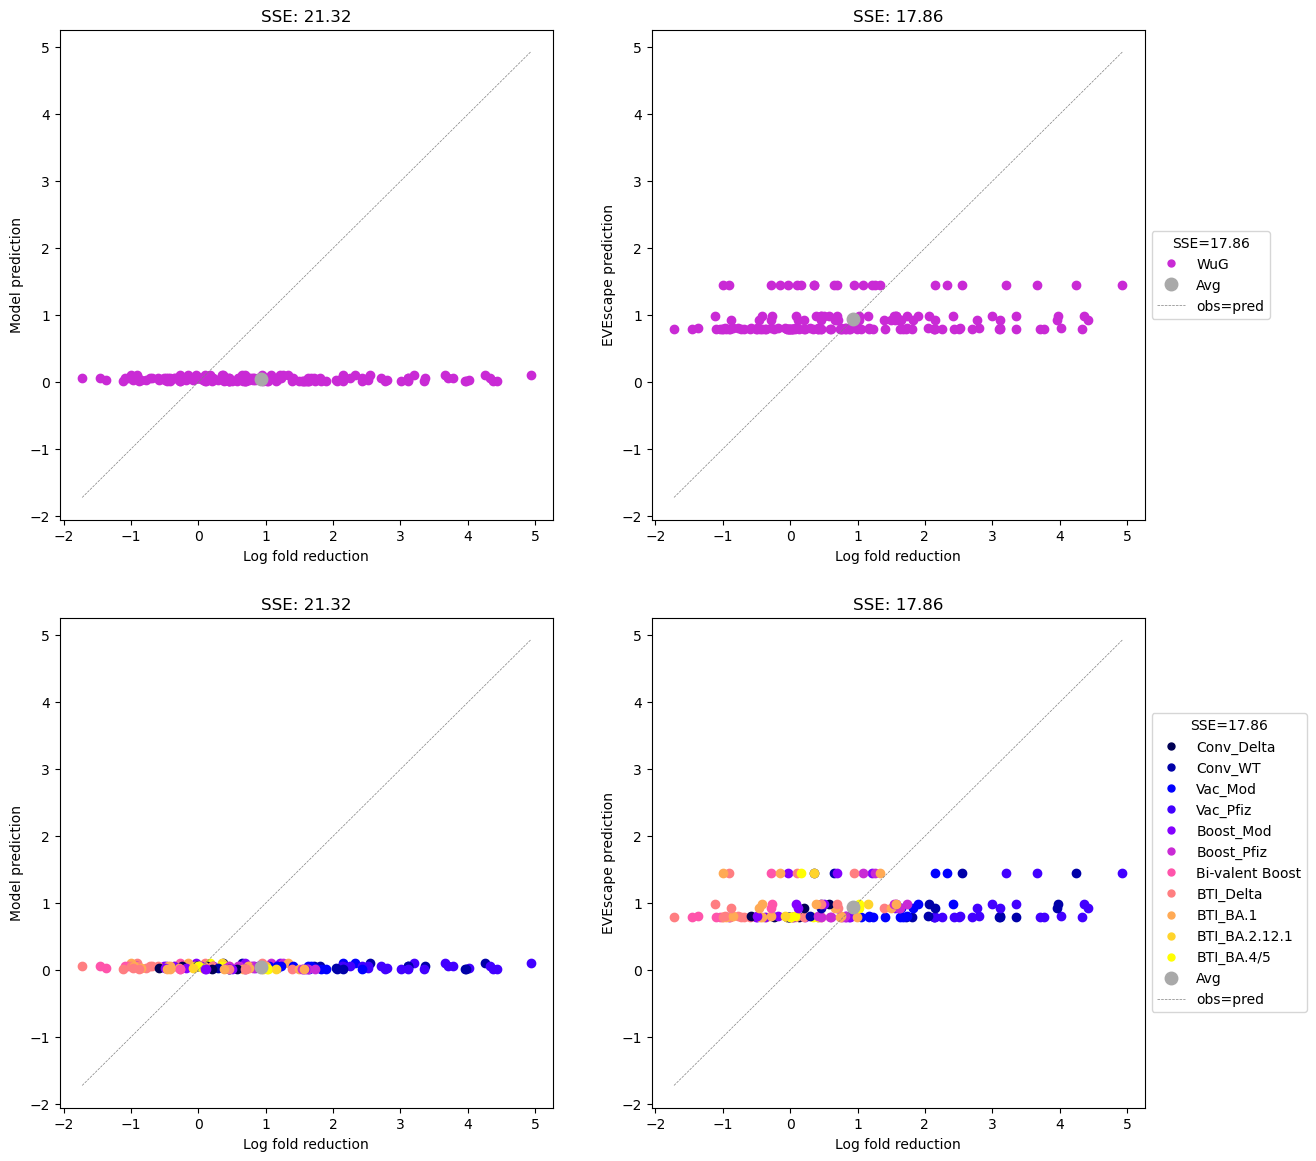

In [12]:
predicted_experiments = neutralization.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14,14))
hues = ['Base VoC', 'Pool']
predictions = ['Model prediction', 'EVEscape prediction']
for k, prediction in enumerate(predictions):
    for hue, ax in zip(hues, axes[:,k]):
        palette = sns.color_palette('gnuplot2', len(neutralization_sub[hue].unique()))
        for i, row in predicted_experiments.iterrows():
            color = palette[neutralization_sub[hue].unique().tolist().index(row[hue])]
            ax.plot(row['Log fold reduction'], row[prediction], 'o', color=color, linestyle='')
            
        line = np.linspace(predicted_experiments[['Log fold reduction', 'EVEscape prediction', 'Model prediction']].min().min(),
                           predicted_experiments[['Log fold reduction', 'EVEscape prediction', 'Model prediction']].max().max())
        ax.plot(line, line, linestyle='--', linewidth=0.5, color='gray')

        obs = predicted_experiments['Log fold reduction']
        preds = predicted_experiments[prediction]
        center = (np.array(obs).sum() / len(obs), np.array(preds).sum() / len(preds))
        ax.plot(center[0], center[1], 'o', color='darkgray', markersize=9)

        SSE = np.sqrt(((np.array(obs) - np.array(preds))**2).sum())
        ax.set_title(f'SSE: {SSE:.2f}')
        
        ax.set_ylabel(prediction)
        ax.set_xlabel('Log fold reduction')

        if ax in axes[:, -1]:
            legend_elements = [Line2D([0], [0], marker='o', linestyle='', color=c, markersize=5, label=l) for c,l in zip(palette, neutralization_sub[hue].unique())] + \
                              [Line2D([0], [0], marker='o', linestyle='', color='darkgray', markersize=9, label='Avg'),
                               Line2D([0], [0], linestyle='--', color='gray', linewidth=0.5, label='obs=pred')]
            ax.legend(handles=legend_elements, title=f'SSE={SSE:.2f}', loc='center left', bbox_to_anchor=[1, 0.5])


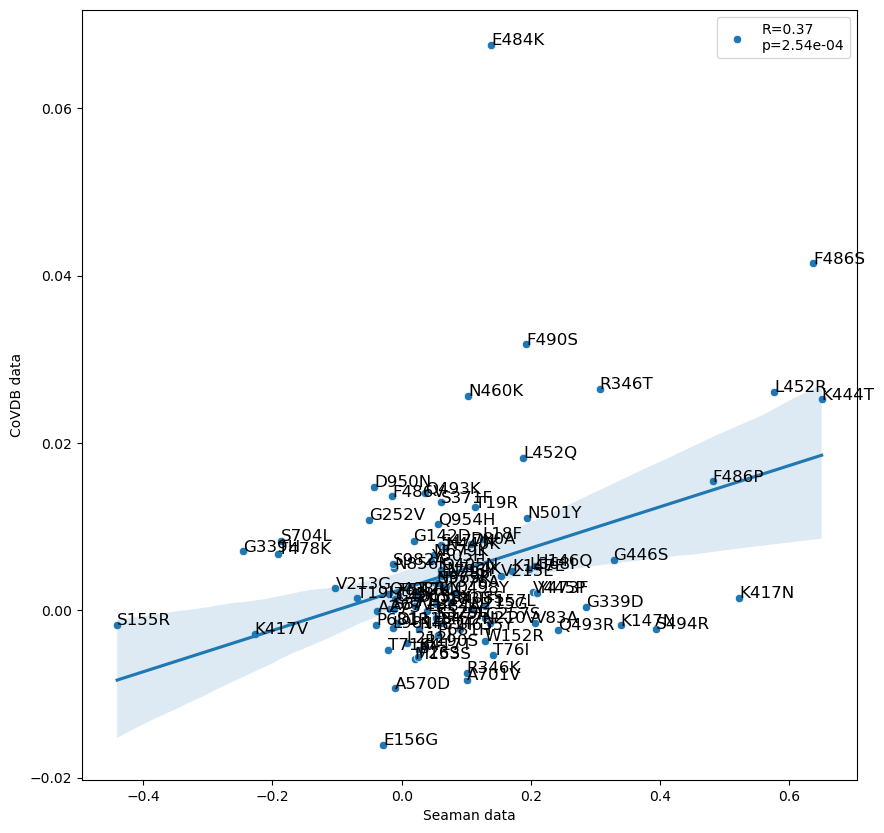

In [13]:
covdb_x_neut = pd.merge(covdb, neut, on='Mutation')
covdb_x_neut_mean = pd.merge(covdb, neut_avg, on='Mutation')

fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(x='Mean Effect',
                y='μ_β',
                # hue='Pool',
                data=covdb_x_neut_mean,
                ax=ax);
sns.regplot(x='Mean Effect',
            y='μ_β',
            # hue='Pool',
            data=covdb_x_neut_mean,
            scatter=False,
            ax=ax);
R, p = corr('Mean Effect', 'μ_β', covdb_x_neut_mean)
ax.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])

for i, row in covdb_x_neut_mean.iterrows():
    ax.text(row['Mean Effect'], row['μ_β'], row['Mutation'], fontsize=12);
    
# line = np.linspace(covdb_x_neut[['Mean Effect', 'μ_β']].min().min(), covdb_x_neut[['Mean Effect', 'μ_β']].max().max())
# ax.plot(line, line, linestyle='--', linewidth=0.5)
ax.set_xlabel('Seaman data');
ax.set_ylabel('CoVDB data');

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


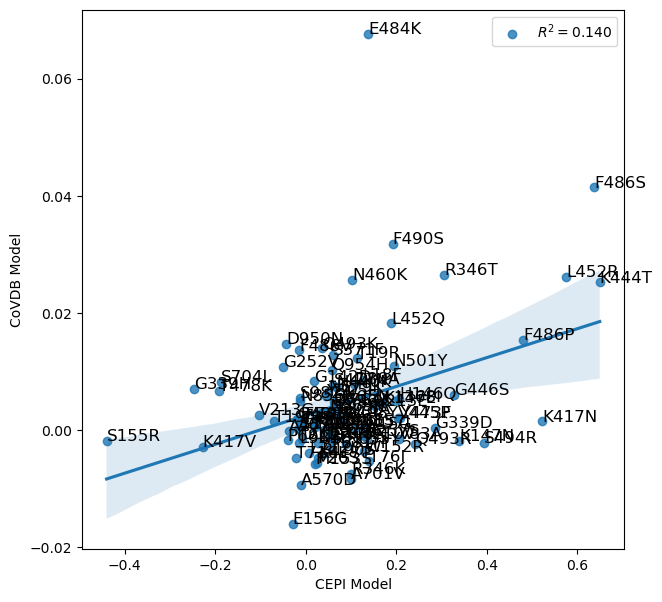

In [14]:
fig, ax = plt.subplots(figsize=(7,7))
p = sns.regplot(x='Mean Effect',
                y='μ_β',
                data=covdb_x_neut_mean,
                ax=ax)
for i, row in covdb_x_neut_mean.iterrows():
    ax.text(row['Mean Effect'], row['μ_β'], row['Mutation'], fontsize=12);

slope, intercept, r_value, p_value, std_err = linregress(covdb_x_neut_mean['μ_β'], covdb_x_neut_mean['Mean Effect'])
# r2 = r2_score(covdb_x_neut_mean['μ_β_q'], covdb_x_neut_mean['Mean Effect'])

ax.legend([f'$R^2 = {r_value**2:.3f}$'], loc="best", frameon=True);

ax.set_xlabel('CEPI Model');
ax.set_ylabel('CoVDB Model');

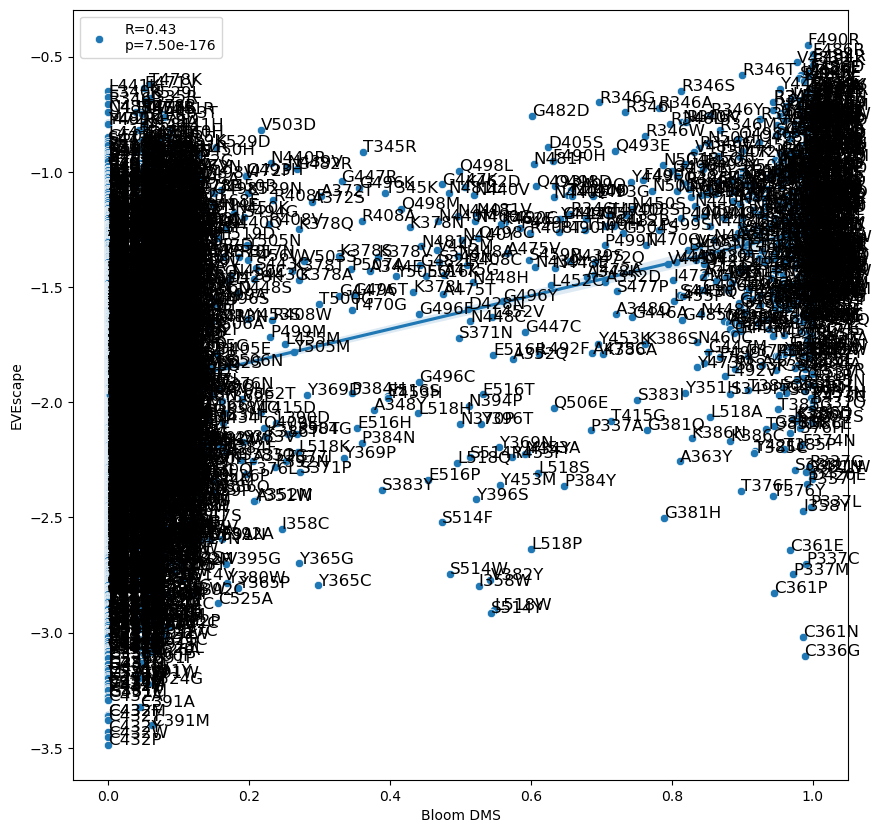

In [15]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(x='max_escape_bloom',
                y='evescape',
                # hue='Pool',
                data=evescape[['max_escape_bloom', 'evescape', 'Mutation']].dropna(),
                ax=ax);
sns.regplot(x='max_escape_bloom',
            y='evescape',
            # hue='Pool',
            data=evescape[['max_escape_bloom', 'evescape', 'Mutation']].dropna(),
            scatter=False,
            ax=ax);
R, p = corr('max_escape_bloom', 'evescape', evescape[['max_escape_bloom', 'evescape', 'Mutation']].dropna())
ax.legend(labels=['R={:.2f}\np={:.2e}'.format(R,p)])

for i, row in evescape[['max_escape_bloom', 'evescape', 'Mutation']].dropna().iterrows():
    ax.text(row['max_escape_bloom'], row['evescape'], row['Mutation'], fontsize=12);
    
# line = np.linspace(covdb_x_neut[['Mean Effect', 'μ_β']].min().min(), covdb_x_neut[['Mean Effect', 'μ_β']].max().max())
# ax.plot(line, line, linestyle='--', linewidth=0.5)
ax.set_xlabel('Bloom DMS');
ax.set_ylabel('EVEscape');

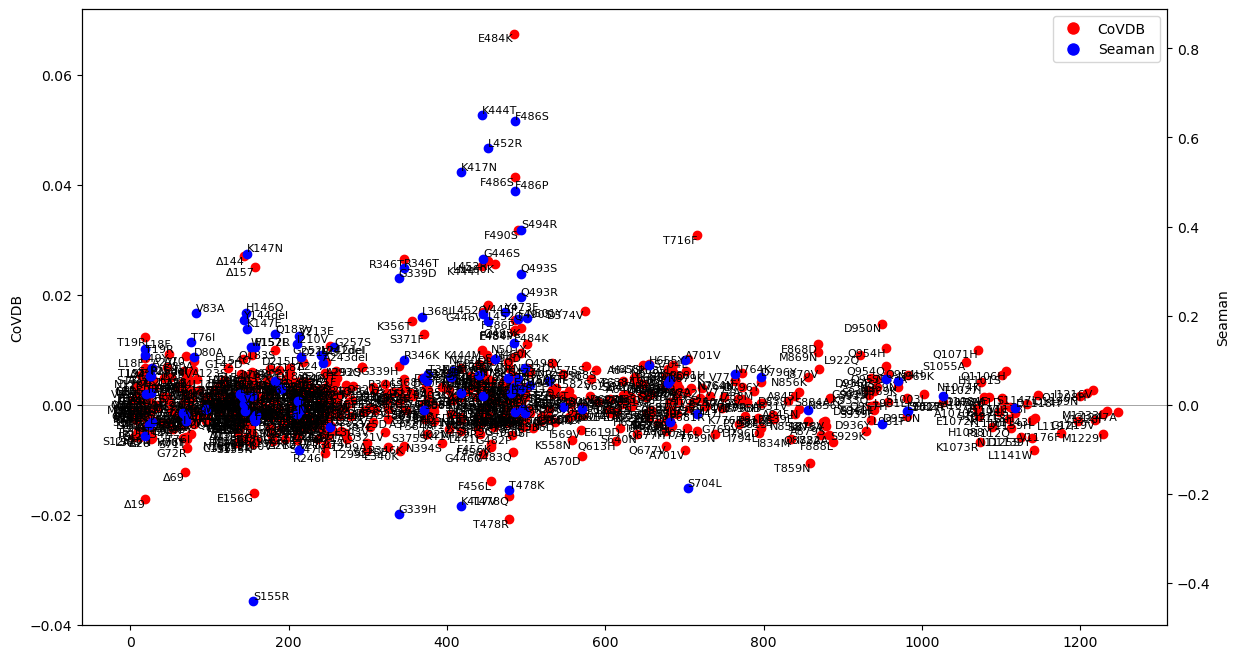

In [16]:
fig, ax = plt.subplots(figsize=(14,8))
fontsize = 8

def get_mut_positions(mutations):
    positions = [int(''.join(filter(str.isdigit, m))) for m in mutations]
    return positions

def align_yaxes(ax1, ax2):
    y_lims = np.array([ax.get_ylim() for ax in [ax1, ax2]])

    # force 0 to appear on both axes, comment if don't need
    y_lims[:, 0] = y_lims[:, 0].clip(None, 0)
    y_lims[:, 1] = y_lims[:, 1].clip(0, None)

    # normalize both axes
    y_mags = (y_lims[:,1] - y_lims[:,0]).reshape(len(y_lims),1)
    y_lims_normalized = y_lims / y_mags

    # find combined range
    y_new_lims_normalized = np.array([np.min(y_lims_normalized), np.max(y_lims_normalized)])

    # denormalize combined range to get new axes
    new_lim1, new_lim2 = y_new_lims_normalized * y_mags
    ax1.set_ylim(new_lim1)
    ax2.set_ylim(new_lim2)

# Plot CoVDB
positions = get_mut_positions(covdb['Mutation'].tolist())
ax.plot(positions, covdb['μ_β'].tolist(), 'ro');
for _, row in covdb.iterrows():
    pos = get_mut_positions([row['Mutation']])[0]
    ax.text(pos, row['μ_β'], row['Mutation'], ha='right', va='top', fontsize=fontsize);
    
ax.set_ylabel('CoVDB')

# Plot Seaman
ax2 = ax.twinx()
positions = get_mut_positions(neut_avg['Mutation'].tolist())
ax2.plot(positions, neut_avg['Mean Effect'].tolist(), 'bo');
for _, row in neut_avg.iterrows():
    pos = get_mut_positions([row['Mutation']])[0]
    ax2.text(pos, row['Mean Effect'], row['Mutation'], ha='left', va='bottom', fontsize=fontsize);
    
ax2.set_ylabel('Seaman');
    
align_yaxes(ax, ax2);
xlim = ax.get_xlim()
ax.hlines(0, xlim[0], xlim[1], linewidth=0.5, color='gray')
ax.set_xlim(xlim);

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                    for color, label in zip(['red', 'blue'],['CoVDB', 'Seaman'])],
          loc='upper right');

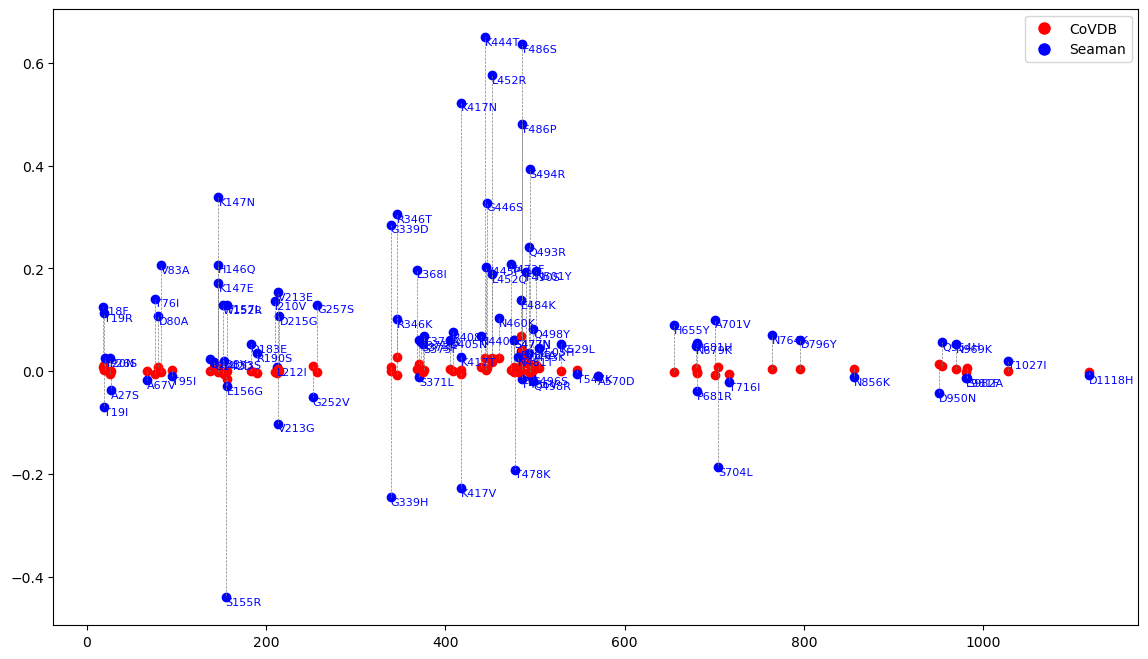

In [17]:
fig, ax = plt.subplots(figsize=(14,8))
fontsize = 8

# Plot covdb_x_neut_mean
for _, row in covdb_x_neut_mean.iterrows():
    pos = get_mut_positions([row['Mutation']])[0]
    # Plot CoVDB
    ax.plot(pos, row['μ_β'], 'ro')
    # Plot Seaman
    ax.plot(pos, row['Mean Effect'], 'bo')
    # Connecting line
    ax.vlines(pos, row['μ_β'], row['Mean Effect'], linestyle='--', linewidth=0.5, color='gray')
    # Annotate
    # Which value is more extreme?
    if np.abs(row['μ_β']) > np.abs(row['Mean Effect']):
        ax.text(pos, row['μ_β'], row['Mutation'], color='red', fontsize=fontsize, ha='left', va='top');
    else:
        ax.text(pos, row['Mean Effect'], row['Mutation'], color='blue', fontsize=fontsize, ha='left', va='top');
        
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                    for color, label in zip(['red', 'blue'],['CoVDB', 'Seaman'])],
          loc='upper right');

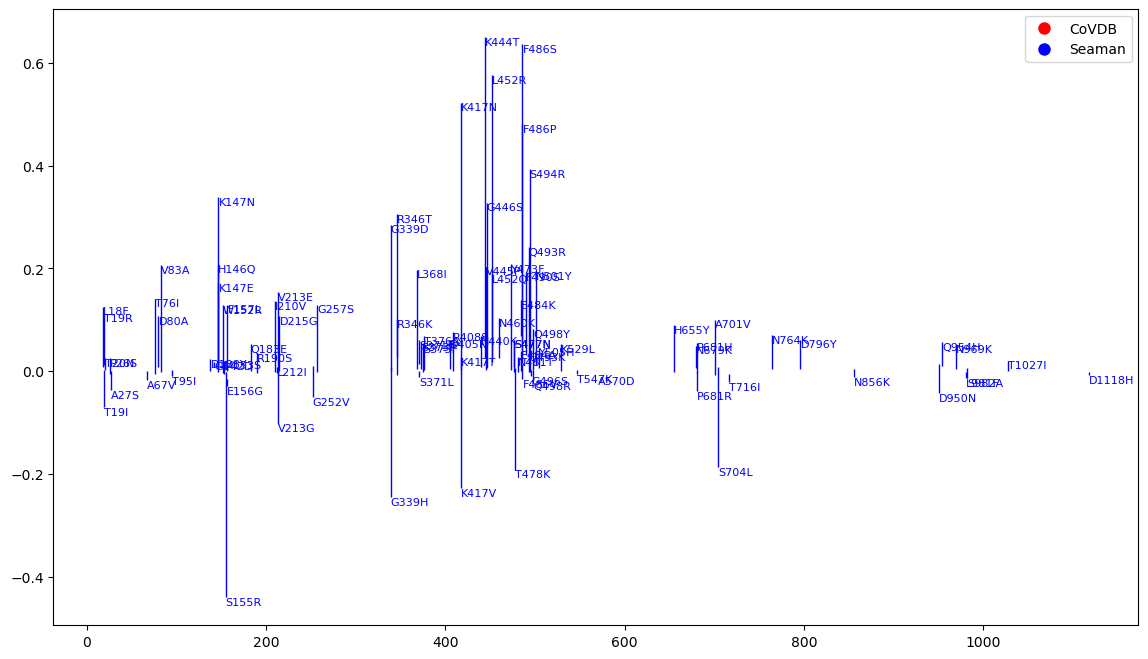

In [18]:
fig, ax = plt.subplots(figsize=(14,8))
fontsize = 8

# Plot covdb_x_neut_mean
for _, row in covdb_x_neut_mean.iterrows():
    pos = get_mut_positions([row['Mutation']])[0]
    # Annotate
    # Which value is more extreme?
    if np.abs(row['μ_β']) > np.abs(row['Mean Effect']):
        # ax.plot(pos, row['μ_β_q'], 'ro', markersize=2)
        # ax.plot(pos, row['Mean Effect'], 'bo', markersize=1)
        ax.vlines(pos, row['μ_β'], row['Mean Effect'], linestyle='-', linewidth=1, color='red')
        ax.text(pos, row['μ_β'], row['Mutation'], color='red', fontsize=fontsize, ha='left', va='top');
    else:
        ax.vlines(pos, row['μ_β'], row['Mean Effect'], linestyle='-', linewidth=1, color='blue')
        ax.text(pos, row['Mean Effect'], row['Mutation'], color='blue', fontsize=fontsize, ha='left', va='top');
        
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                    for color, label in zip(['red', 'blue'],['CoVDB', 'Seaman'])],
          loc='upper right');

In [19]:
evescape

,i,wt,mut,evescape,evescape_pre2020,eve,eve_pre2020,rsa,wcn,dissimilarity,...,cscs_hie,bloom_expression,bloom_ace2_binding,chan_expression,chan_ace2_binding,rbd_antibody_class_barnes,max_escape_bloom,max_escape_xie,is_escape_experiment,Mutation
0,490,F,R,-0.448666,-0.448132,-4.035376,2.020508,0.791878,-1.029811,4.070201,...,35985.5,-0.05,0.01,1.84,0.92,class 2,0.9925,0.9942,True,F490R
1,683,R,I,-0.484194,-0.520918,-3.485986,0.120215,0.711196,-1.157835,4.291281,...,39275.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R683I
2,158,R,I,-0.485720,-0.463482,-7.626001,0.284741,0.853458,-1.031618,4.291281,...,33998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R158I
3,486,F,R,-0.490110,-0.514365,-9.563061,-2.406641,0.918782,-0.825890,4.070201,...,46892.5,0.15,-0.38,1.16,-0.54,class 2,1.0000,0.9788,True,F486R
4,145,Y,R,-0.491732,-0.472427,-5.971094,1.788525,0.853458,-0.830025,2.983220,...,24781.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y145R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24182,999,G,M,-4.789753,-4.661656,-22.157910,-10.427344,0.107143,-2.574441,-1.977659,...,18953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G999M
24183,1032,C,A,-4.803132,-4.858449,-22.446118,-11.240698,0.034449,-2.569813,-1.775001,...,38968.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C1032A
24184,999,G,Y,-4.803356,-4.699346,-22.287769,-10.603760,0.107143,-2.574441,-1.903965,...,19976.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G999Y
24185,749,C,Y,-4.838374,-4.754821,-22.495264,-10.822363,0.433347,-2.549036,-2.125046,...,47608.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C749Y


In [20]:
covdb

,Mutation,μ_β,σ_β,N
0,A1070S,-0.000614,0.135301,31
1,A1078T,0.000891,0.132982,4
2,A1078V,0.001429,0.140557,1
3,A123S,0.006714,0.148183,27
4,A163Y,0.000407,0.143815,4
...,...,...,...,...
769,Δ74,0.004297,0.148764,31
770,Δ75,-0.002493,0.129384,27
771,Δ76,0.002449,0.138556,27
772,Δ77,-0.003178,0.143413,27


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


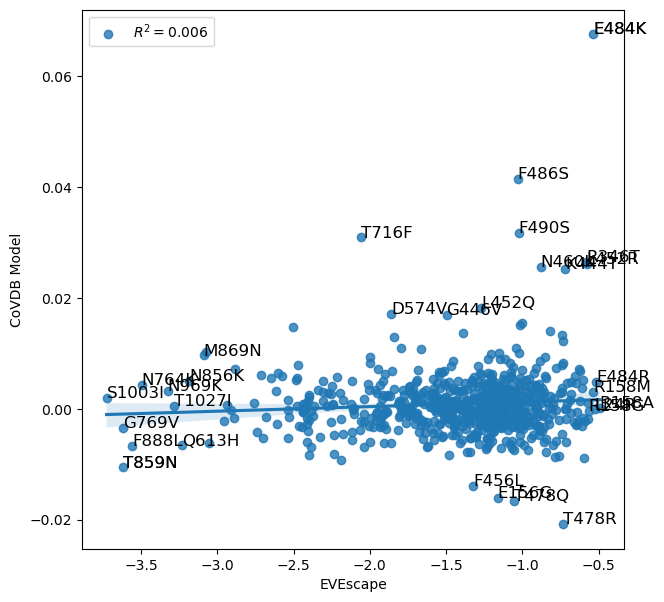

In [21]:
covdb_x_evescape = pd.merge(covdb, evescape, on='Mutation')

fig, ax = plt.subplots(figsize=(7,7))
p = sns.regplot(x='evescape',
                y='μ_β',
                data=covdb_x_evescape,
                ax=ax)
for i, row in covdb_x_evescape.sort_values(by='μ_β', ascending=False).reset_index(drop=True).iterrows():
    if i <= 10:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
    if i >= len(covdb_x_evescape)-5:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
for i, row in covdb_x_evescape.sort_values(by='evescape', ascending=False).reset_index(drop=True).iterrows():
    if i <= 5:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
    if i >= len(covdb_x_evescape)-10:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);

slope, intercept, r_value, p_value, std_err = linregress(covdb_x_evescape['μ_β'], covdb_x_evescape['evescape'])
# r2 = r2_score(covdb_x_neut_mean['μ_β_q'], covdb_x_neut_mean['Mean Effect'])

ax.legend([f'$R^2 = {r_value**2:.3f}$'], loc="best", frameon=True);

ax.set_xlabel('EVEscape');
ax.set_ylabel('CoVDB Model');

KeyError: 'evescape'

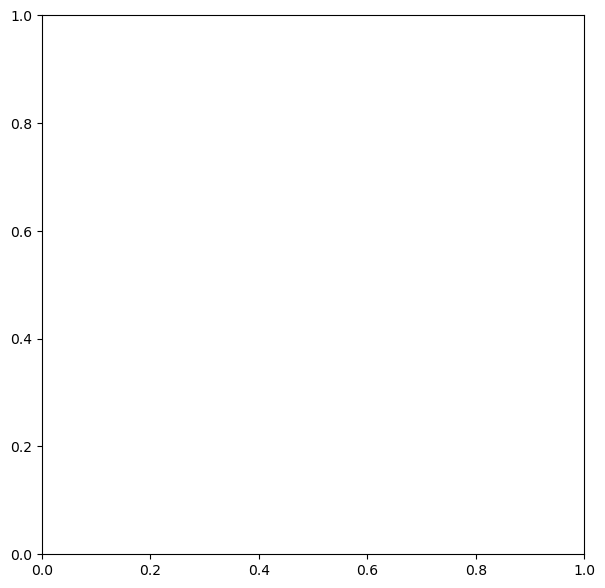

In [22]:
covdb_x_dms = pd.merge(covdb, dms, on='Mutation')

fig, ax = plt.subplots(figsize=(7,7))
p = sns.regplot(x='evescape',
                y='μ_β',
                data=covdb_x_dms,
                ax=ax)
for i, row in covdb_x_dms.sort_values(by='μ_β', ascending=False).reset_index(drop=True).iterrows():
    if i <= 10:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
    if i >= len(covdb_x_dms)-5:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
for i, row in covdb_x_dms.sort_values(by='evescape', ascending=False).reset_index(drop=True).iterrows():
    if i <= 5:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);
    if i >= len(covdb_x_dms)-10:
        ax.text(row['evescape'], row['μ_β'], row['Mutation'], fontsize=12);

slope, intercept, r_value, p_value, std_err = linregress(covdb_x_dms['μ_β'], covdb_x_dms['evescape'])
# r2 = r2_score(covdb_x_neut_mean['μ_β_q'], covdb_x_neut_mean['Mean Effect'])

ax.legend([f'$R^2 = {r_value**2:.3f}$'], loc="best", frameon=True);

ax.set_xlabel('EVEscape');
ax.set_ylabel('CoVDB Model');